In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [89]:
# Importing the dataset
from sklearn.datasets import make_classification

In [90]:
X,y = make_classification(n_samples = 1000, n_features = 2, n_classes = 2,n_redundant = 0
                          , n_clusters_per_class=2)

In [91]:
X

array([[ 1.68401992,  0.02752329],
       [-1.20038145,  0.77296459],
       [ 1.09772326,  1.31442103],
       ...,
       [-0.46610145, -0.67114262],
       [-1.34226639,  0.33082503],
       [-1.20705121,  0.64483028]], shape=(1000, 2))

In [92]:
pd.DataFrame(X)[0]

0      1.684020
1     -1.200381
2      1.097723
3      0.666911
4     -1.208358
         ...   
995    0.232308
996   -0.824521
997   -0.466101
998   -1.342266
999   -1.207051
Name: 0, Length: 1000, dtype: float64

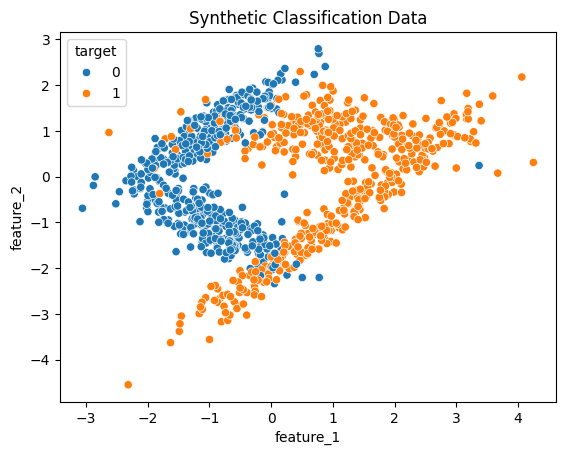

In [93]:
df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["target"] = y

sns.scatterplot(data=df, x="feature_1", y="feature_2", hue="target")
plt.title("Synthetic Classification Data")
plt.show()

In [94]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = .30,random_state = 42)

In [95]:
from sklearn.svm import SVC

In [96]:
svc = SVC(kernel= 'linear')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)

In [97]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       163
           1       0.89      0.85      0.87       137

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300

[[148  15]
 [ 20 117]]


In [98]:
rbf = SVC(kernel= 'rbf')
rbf.fit(X_train,y_train)
y_pred1 = rbf.predict(X_test)

print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))


              precision    recall  f1-score   support

           0       0.92      0.95      0.94       163
           1       0.94      0.91      0.92       137

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

[[155   8]
 [ 13 124]]


In [99]:
poli = SVC(kernel= 'poly')
poli.fit(X_train,y_train)
y_pred2= poli.predict(X_test)

print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       163
           1       0.88      0.83      0.85       137

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

[[147  16]
 [ 23 114]]


In [100]:
sig = SVC(kernel= 'sigmoid')
sig.fit(X_train,y_train)
y_pred3= sig.predict(X_test)

print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77       163
           1       0.72      0.73      0.73       137

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300

[[125  38]
 [ 37 100]]


# Hyperparameter tuning

In [101]:
from sklearn.model_selection import GridSearchCV
params = {
	"C": [100, 10, 1.0, 0.1, 0.01],
	"kernel": ["linear", "rbf", "poly", "sigmoid"],
	"gamma": ["scale", "auto"]
}

grid = GridSearchCV(SVC(), param_grid=params, refit=True, cv=5, verbose=3)

In [102]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END .C=100, gamma=scale, kernel=linear;, score=0.857 total time=   0.0s
[CV 2/5] END .C=100, gamma=scale, kernel=linear;, score=0.850 total time=   0.0s
[CV 3/5] END .C=100, gamma=scale, kernel=linear;, score=0.907 total time=   0.0s
[CV 4/5] END .C=100, gamma=scale, kernel=linear;, score=0.879 total time=   0.0s
[CV 5/5] END .C=100, gamma=scale, kernel=linear;, score=0.893 total time=   0.0s
[CV 1/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.936 total time=   0.0s
[CV 2/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.957 total time=   0.0s
[CV 3/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.950 total time=   0.0s
[CV 4/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.929 total time=   0.0s
[CV 5/5] END ....C=100, gamma=scale, kernel=rbf;, score=0.929 total time=   0.0s
[CV 1/5] END ...C=100, gamma=scale, kernel=poly;, score=0.871 total time=   0.0s
[CV 2/5] END ...C=100, gamma=scale, kernel=poly

,estimator,SVC()
,param_grid,"{'C': [100, 10, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [103]:
grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [104]:
y_pred4 = grid.predict(X_test)
print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       163
           1       0.94      0.91      0.93       137

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

[[155   8]
 [ 12 125]]
